In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import rasterio

In [2]:
#set paths 
#base_dir = "/Users/sofiasuhinin/Desktop/Subglacial_Lakes_Data"
base_dir = r"C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_Subglacial_Lakes\Notebooks\Subglacial_Lakes_Data"
lake_location_path = os.path.join(base_dir, "lake_locations.csv")
lake_and_null_path = os.path.join(base_dir, "lake_and_null_loc.csv")
dataset_split_path = os.path.join(base_dir, "dataset_split.csv")
lake_masks = os.path.join(base_dir, "lake_masks")
training_set = os.path.join(base_dir, "lakesTS_2")

# import data
lake_location = pd.read_csv(lake_location_path)
lake_and_null = pd.read_csv(lake_and_null_path)
dataset_split = pd.read_csv(dataset_split_path)

# list all netcdf files in each folder
tile_files = sorted([f for f in os.listdir(training_set) if f.endswith(".nc")])
mask_files = sorted([f for f in os.listdir(lake_masks) if f.endswith(".nc")])

print("number of training files:", len(tile_files))
print("number of lake mask files:", len(mask_files))
    # we expect a difference because there are some null training files - i.e., where there are not lakes = no lake masks

print(tile_files[:10])
print(mask_files[:10])

number of training files: 105
number of lake mask files: 85
['ANZAC19.nc', 'Academy45.nc', 'Academy91.nc', 'Adams17.nc', 'Adams19.nc', 'Amery22.nc', 'Beardmore107.nc', 'Beardmore18.nc', 'Beardmore66.nc', 'Beaver27.nc']
['ANZAC19_mask.nc', 'Academy45_mask.nc', 'Academy91_mask.nc', 'Adams17_mask.nc', 'Adams19_mask.nc', 'Amery22_mask.nc', 'Beardmore107_mask.nc', 'Beardmore18_mask.nc', 'Beardmore66_mask.nc', 'Beaver27_mask.nc']


In [3]:
# create a dataframe to hold the corresponding tile paths, mask paths, and labels (has lake or not)
rows = []

for tile in tile_files:
    
    name = tile.replace(".nc", "")
    
    tile_path = os.path.join(training_set, tile)
    
    mask_file = f"{name}_mask.nc"
    mask_path = os.path.join(lake_masks, mask_file)
    
    if os.path.exists(mask_path):
        has_mask = True
    else:
        mask_path = None
        has_mask = False
    
    rows.append({
        "name": name,
        "tile_path": tile_path,
        "mask_path": mask_path,
        "has_lake": int(has_mask)
    })

dataset_df = pd.DataFrame(rows)

# import class information (train, val, test) based on dataset_split.csv
dataset_split["file_name"] = (
    dataset_split["file"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .str.split("/")
    .str[-1]
)

# isolate the name of the lake from the file path
dataset_split["name"] = dataset_split["file_name"].str.replace(".nc", "", regex=False)

# merge split with dataset dataframe
dataset_df = dataset_df.merge(
    dataset_split[["name", "dataset"]],
    on="name",
    how="left"
)

print(dataset_df.head())
print()
print(dataset_df["dataset"].value_counts())

        name                                          tile_path  \
0    ANZAC19  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
1  Academy45  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
2  Academy91  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
3    Adams17  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
4    Adams19  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   

                                           mask_path  has_lake dataset  
0  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1    test  
1  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
2  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
3  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
4  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1    test  

dataset
train    73
test     16
val      16
Name: count, dtype: int64


In [4]:
# break dataset into 3 categories
train_df = dataset_df[dataset_df["dataset"] == "train"].reset_index(drop=True)
val_df = dataset_df[dataset_df["dataset"] == "val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["dataset"] == "test"].reset_index(drop=True)

#confirm
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))
print(train_df.head())

train: 73
validation: 16
test: 16
           name                                          tile_path  \
0     Academy45  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
1     Academy91  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
2       Adams17  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
3       Amery22  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   
4  Beardmore107  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...   

                                           mask_path  has_lake dataset  
0  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
1  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
2  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
3  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  
4  C:\Users\cambo\Desktop\ML-26\blank\MLGEO2026_S...         1   train  


In [5]:
class LakeSegmentationDataset(Dataset):
    # define dataset to be used by PyTorch
    def __init__(self, dataframe, tile_var="anomaly", mask_var="lake_mask"):
        self.df = dataframe.reset_index(drop=True)
        self.tile_var = tile_var
        self.mask_var = mask_var

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # load tile
        tile_ds = xr.open_dataset(row["tile_path"])
        arr = tile_ds[self.tile_var].values.astype(np.float32)   # (time, y, x)
        tile_ds.close()

        # collapse time into 2 channels: mean and std
        valid = np.isfinite(arr)
        valid_count = valid.sum(axis=0)

        arr_zeroed = np.where(valid, arr, 0.0)
        mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)

        diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
        std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))

        mean_img[valid_count == 0] = 0.0
        std_img[valid_count == 0] = 0.0

        x = np.stack([mean_img, std_img], axis=0)   # (2, H, W)

        # NORMALIZE USING GLOBAL STATISTICS (pre-computed)
        # calculate global mean and std from training set (done once, then hardcoded here)
        GLOBAL_MEAN_MEAN = -2.4824232087901197 
        GLOBAL_STD_MEAN = 20.268677019954087   
        GLOBAL_STD_STD = 3.7701363263330427   
    
        x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN  # normalize mean channel
        x[1] = x[1] / GLOBAL_STD_STD                         # normalize std channel

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        # load mask
        if pd.isna(row["mask_path"]) or row["mask_path"] is None:
            mask = np.zeros((x.shape[1], x.shape[2]), dtype=np.float32)
        else:
            mask_ds = xr.open_dataset(row["mask_path"])
            mask = mask_ds[self.mask_var].values.astype(np.float32)   # (y, x)
            mask_ds.close()

        # force binary
        mask = (mask > 0).astype(np.float32)

        # add channel dim
        mask = np.expand_dims(mask, axis=0)   # (1, H, W)

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32)
        )

In [6]:
# declare each of the 3 classes (train, val, test) as a dataset
train_dataset = LakeSegmentationDataset(train_df, tile_var="anomaly", mask_var="lake_mask")
val_dataset = LakeSegmentationDataset(val_df, tile_var="anomaly", mask_var="lake_mask")
test_dataset = LakeSegmentationDataset(test_df, tile_var="anomaly", mask_var="lake_mask")

In [7]:
# instead of computing mean and std per image in the __getitem__ method, compute global avg here 
# only needs to happen once
'''
all_mean_imgs = []
all_std_imgs = []

for idx in range(len(train_dataset)):  # Use your train_dataset
    row = train_dataset.df.iloc[idx]
    
    # Load tile
    tile_ds = xr.open_dataset(row["tile_path"])
    arr = tile_ds["anomaly"].values.astype(np.float32)  # Use your tile_var name
    tile_ds.close()
    
    # Compute mean and std images (same as in __getitem__)
    valid = np.isfinite(arr)
    valid_count = valid.sum(axis=0)
    
    arr_zeroed = np.where(valid, arr, 0.0)
    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
    
    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
    
    mean_img[valid_count == 0] = 0.0
    std_img[valid_count == 0] = 0.0
    
    # Store flattened values
    all_mean_imgs.append(mean_img.flatten())
    all_std_imgs.append(std_img.flatten())

# Concatenate all values
all_mean_imgs = np.concatenate(all_mean_imgs)
all_std_imgs = np.concatenate(all_std_imgs)

# Compute statistics
GLOBAL_MEAN_MEAN = all_mean_imgs.mean()
GLOBAL_STD_MEAN = all_mean_imgs.std()
GLOBAL_STD_STD = all_std_imgs.std()

print(f"GLOBAL_MEAN_MEAN = {GLOBAL_MEAN_MEAN}")
print(f"GLOBAL_STD_MEAN = {GLOBAL_STD_MEAN}")
print(f"GLOBAL_STD_STD = {GLOBAL_STD_STD}")
'''

'\nall_mean_imgs = []\nall_std_imgs = []\n\nfor idx in range(len(train_dataset)):  # Use your train_dataset\n    row = train_dataset.df.iloc[idx]\n\n    # Load tile\n    tile_ds = xr.open_dataset(row["tile_path"])\n    arr = tile_ds["anomaly"].values.astype(np.float32)  # Use your tile_var name\n    tile_ds.close()\n\n    # Compute mean and std images (same as in __getitem__)\n    valid = np.isfinite(arr)\n    valid_count = valid.sum(axis=0)\n\n    arr_zeroed = np.where(valid, arr, 0.0)\n    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)\n\n    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)\n    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))\n\n    mean_img[valid_count == 0] = 0.0\n    std_img[valid_count == 0] = 0.0\n\n    # Store flattened values\n    all_mean_imgs.append(mean_img.flatten())\n    all_std_imgs.append(std_img.flatten())\n\n# Concatenate all values\nall_mean_imgs = np.concatenate(all_mean_imgs)\nall_std_imgs = np.concate

In [8]:
# break training data into inputs & outputs (mask)
X, y = train_dataset[0]

print("Input shape:", X.shape)
print("Mask shape:", y.shape)
print("Mask unique values:", torch.unique(y))

Input shape: torch.Size([2, 501, 501])
Mask shape: torch.Size([1, 501, 501])
Mask unique values: tensor([0., 1.])


In [9]:
# load datasets using PyTorch DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
X_batch, y_batch = next(iter(train_loader))

print("Batch input shape:", X_batch.shape)
print("Batch mask shape:", y_batch.shape)

Batch input shape: torch.Size([1, 2, 501, 501])
Batch mask shape: torch.Size([1, 1, 501, 501])


In [10]:
# image convolution
class UNet(nn.Module):

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = conv_block(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = conv_block(64, 32)

        self.final = nn.Conv2d(32, out_channels, 1)

    def _match_size(self, src, target):
        """
        Resize src spatial dims to match target spatial dims.
        src: tensor to resize
        target: tensor whose H,W we want
        """
        if src.shape[-2:] != target.shape[-2:]:
            src = F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        e1 = self.enc1(x)                  # [B, 32, 501, 501]
        e2 = self.enc2(self.pool1(e1))     # [B, 64, 250, 250]
        e3 = self.enc3(self.pool2(e2))     # [B, 128, 125, 125]

        b = self.bottleneck(self.pool3(e3))  # [B, 256, 62, 62]

        d3 = self.up3(b)                   # may be [B, 128, 124, 124]
        d3 = self._match_size(d3, e3)      # force to [B, 128, 125, 125]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = self._match_size(out, x)   # just to be safe
        return out

In [11]:
# create model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # checks if GPU is available for faster training
model = UNet(in_channels=2, out_channels=1).to(device) # creates U Net architecture and moves it to GPU if available

# Give more penalty for missing lake pixels (false negatives)
pos_weight = torch.tensor([5.0]).to(device)  # Weight for positive class
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # uses Binary Cross Entropy; combines sigmois & loss in one step 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # learning rate optimization

In [12]:
# training functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)              # [B, 1, H, W]
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item() * X.size(0)

    return total_loss / len(loader.dataset)

In [13]:
# training loop
num_epochs = 30

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/30 | Train Loss: 0.6566 | Val Loss: 0.4488
Epoch 2/30 | Train Loss: 0.4138 | Val Loss: 0.3781
Epoch 3/30 | Train Loss: 0.3812 | Val Loss: 0.3452
Epoch 4/30 | Train Loss: 0.3454 | Val Loss: 0.3010
Epoch 5/30 | Train Loss: 0.3079 | Val Loss: 0.3450
Epoch 6/30 | Train Loss: 0.3048 | Val Loss: 0.2555
Epoch 7/30 | Train Loss: 0.2966 | Val Loss: 0.2708
Epoch 8/30 | Train Loss: 0.3026 | Val Loss: 0.2682
Epoch 9/30 | Train Loss: 0.3105 | Val Loss: 0.2570
Epoch 10/30 | Train Loss: 0.2928 | Val Loss: 0.2845
Epoch 11/30 | Train Loss: 0.2765 | Val Loss: 0.2588
Epoch 12/30 | Train Loss: 0.2721 | Val Loss: 0.2512
Epoch 13/30 | Train Loss: 0.2668 | Val Loss: 0.2519
Epoch 14/30 | Train Loss: 0.2752 | Val Loss: 0.2838
Epoch 15/30 | Train Loss: 0.2651 | Val Loss: 0.2535
Epoch 16/30 | Train Loss: 0.2667 | Val Loss: 0.2421
Epoch 17/30 | Train Loss: 0.2568 | Val Loss: 0.2698
Epoch 18/30 | Train Loss: 0.2596 | Val Loss: 0.2579
Epoch 19/30 | Train Loss: 0.2493 | Val Loss: 0.2265
Epoch 20/30 | Train L

In [14]:
# measure how well predicted masks overlap with true masks
def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3)) # finds true positives
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) # predicted positives + actual positives

    dice = (2 * intersection + eps) / (union + eps) # ranges 0-1 w/ 1 being perfect overlap
    return dice.mean().item()


def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3)) # finds true positives
    total = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    union = total - intersection # predicted positives + actual positives - true positives = false positives + false negatives

    iou = (intersection + eps) / (union + eps) # ranges 0-1 w/ 1 being perfect
    return iou.mean().item()

In [15]:
# evaluate model learning based on validation data using loss, dice score, and iou score
@torch.no_grad()
def evaluate_segmentation(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_dice += dice_score_from_logits(logits, y)
        total_iou += iou_score_from_logits(logits, y)
        n_batches += 1

    return {
        "loss": total_loss / n_batches,
        "dice": total_dice / n_batches,
        "iou": total_iou / n_batches,
    }

In [16]:
# run evaluation on validation and test sets
val_metrics = evaluate_segmentation(model, val_loader, criterion, device)
test_metrics = evaluate_segmentation(model, test_loader, criterion, device)

print("Validation Metrics:")
print(val_metrics)

print("\nTest Metrics:")
print(test_metrics)

Validation Metrics:
{'loss': 0.2241731567773968, 'dice': 0.4826665036467998, 'iou': 0.3522570887668221}

Test Metrics:
{'loss': 0.30904141266364604, 'dice': 0.38593463463053007, 'iou': 0.29910134853139425}


In [19]:
# plotting script
@torch.no_grad()
def plot_prediction(model, dataset, idx, device, threshold=0.5):
    model.eval()

    X, y = dataset[idx]
    X_in = X.unsqueeze(0).to(device)

    logits = model(X_in)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred = (probs > threshold).astype(float)

    X_np = X.cpu().numpy()
    y_np = y.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(X_np[0], cmap="coolwarm")
    axes[0].set_title("Input: Mean anomaly")
    axes[0].axis("off")

    axes[1].imshow(X_np[1], cmap="viridis")
    axes[1].set_title("Input: Std anomaly")
    axes[1].axis("off")

    axes[2].imshow(y_np, cmap="gray")
    axes[2].set_title("True mask")
    axes[2].axis("off")

    axes[3].imshow(pred, cmap="gray")
    axes[3].set_title("Predicted mask")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

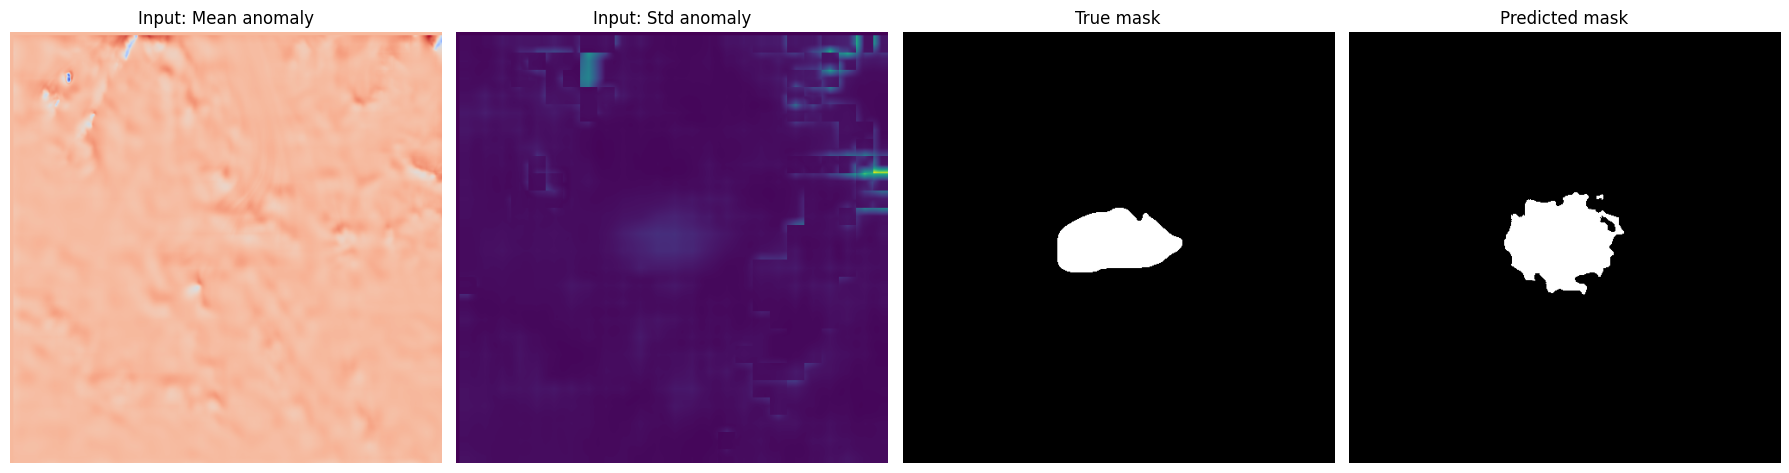

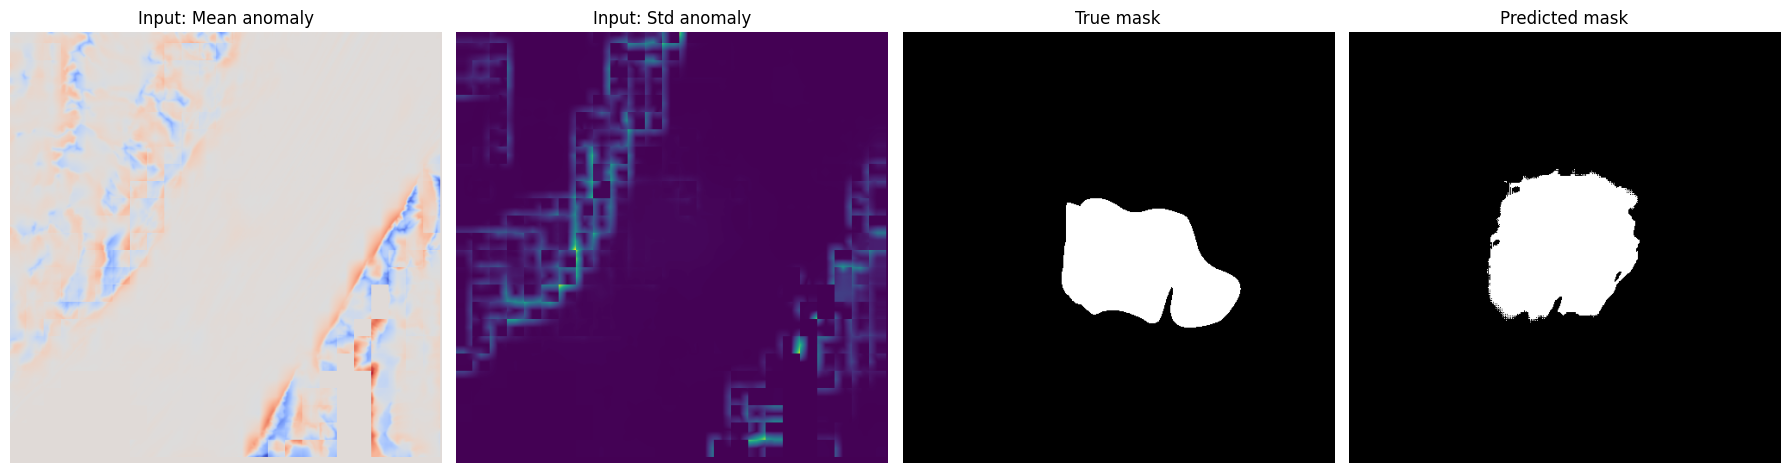

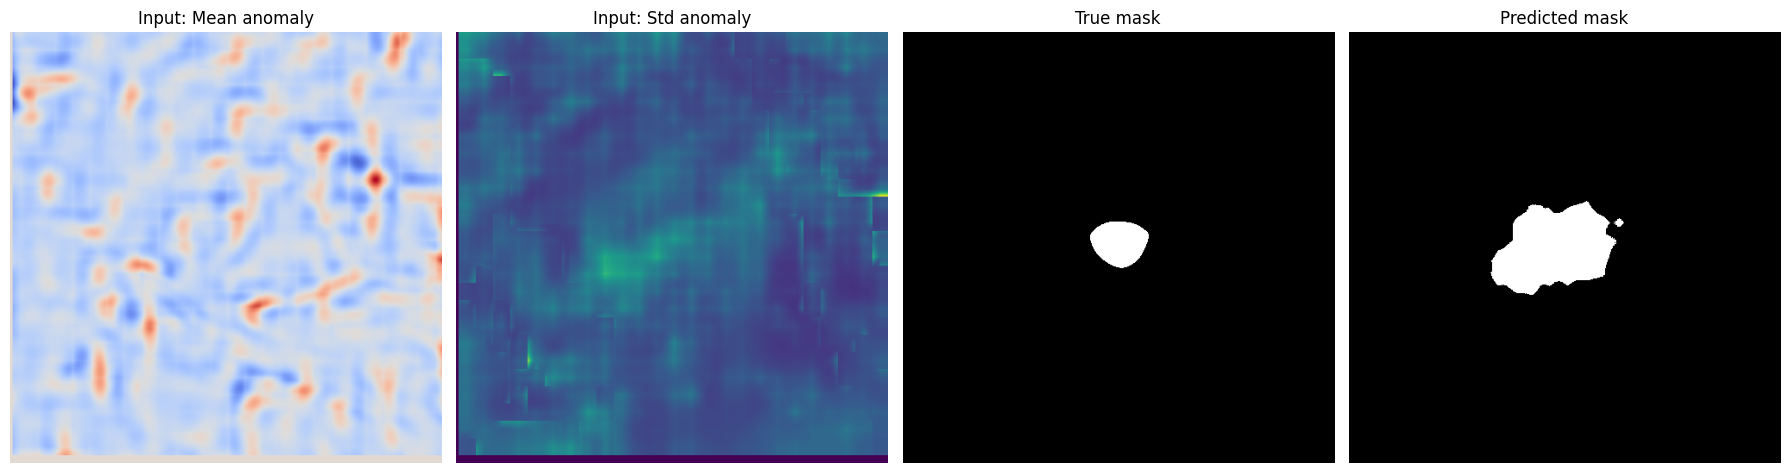

In [20]:
# plot masks
plot_prediction(model, val_dataset, 0, device)
plot_prediction(model, val_dataset, 1, device)
plot_prediction(model, val_dataset, 2, device)